# Step 5 — Cointegration Testing

This is the most important step in the project. Everything before this was setup and exploration. This step answers the question the entire strategy depends on:

> **Is the KO/PEP spread statistically proven to be mean-reverting, or have we just been looking at noise?**

We run three tests in order of increasing rigor:

1. **ADF on each series individually** — confirm both price series are non-stationary (they wander). This is a prerequisite for cointegration to even make sense.
2. **Engle-Granger** — the proper cointegration test when the hedge ratio β was estimated from the data.
3. **Johansen** — a symmetric cross-check that treats both series equally and doesn't require choosing a dependent variable.

If Engle-Granger and Johansen both agree that the spread is cointegrated, we can proceed to the backtest with statistical confidence. If they disagree or both fail, we need to investigate before building anything on top of this.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, str(Path.cwd().parent))

from pairs_trading.data import load_or_fetch
from pairs_trading.spread import estimate_hedge_ratio, build_spread
from pairs_trading.stats import (
    adf_test, print_adf,
    engle_granger_test,
    johansen_test,
    rolling_eg_pvalue,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def fmt_dates(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.figure.autofmt_xdate(rotation=0, ha="center")

In [2]:
prices = load_or_fetch(["KO", "PEP"], "2018-01-01", "2025-01-01", name="ko_pep_7yr")
_, beta, _ = estimate_hedge_ratio(prices)
spread = build_spread(prices, beta)
returns = prices.pct_change().dropna()
print(f"{len(prices)} days loaded  |  β = {beta:.4f}")

Loading from cache: c:\Users\delosreyes.i\Downloads\Quant Claude Project\Pair-Regression-Testing\pairs_trading\data\ko_pep_7yr.parquet


1761 days loaded  |  β = 0.7972


---
## Background: What are we actually testing?

### Stationarity

A series is **stationary** if it fluctuates around a stable mean and doesn't drift away from it permanently. Daily stock returns are stationary — they bounce around near zero forever. Stock *prices* are **not** stationary — they trend upward over decades (or downward for bad companies).

### Unit root

A "unit root" is the mathematical property that makes a series non-stationary. A random walk has a unit root: each day's value is yesterday's value plus random noise, so the series drifts without bound.

The **Augmented Dickey-Fuller (ADF) test** tests for a unit root:
- **Null hypothesis**: the series HAS a unit root (is non-stationary)
- **Rejecting the null** (p < 0.05): the series appears stationary
- **Failing to reject** (p ≥ 0.05): we cannot conclude stationarity — but this is NOT proof of a unit root

This distinction matters. A common mistake is saying "we failed to reject, so the series is a random walk." That's wrong. Failing to reject just means the evidence isn't strong enough — the test has limited power, especially with noisy data.

### I(1) — the prerequisite for cointegration

For cointegration to make sense, both series must be **I(1)**: non-stationary in *levels* (prices drift), but stationary in *first differences* (returns don't drift). Both KO and PEP should pass this check — their prices wander, but their daily returns bounce around near zero.

If one series were already stationary in levels (I(0)), cointegration wouldn't apply — we'd just model it directly.

---
## Test A — ADF on price levels and returns

We run ADF on four series:
- KO log-price levels → expect **non-stationary** (fail to reject unit root)
- PEP log-price levels → expect **non-stationary**
- KO daily returns → expect **stationary** (reject unit root)
- PEP daily returns → expect **stationary**

This confirms both series are I(1) — a prerequisite for cointegration testing.

In [3]:
log_ko  = np.log(prices["KO"])
log_pep = np.log(prices["PEP"])

results_levels = [
    adf_test(log_ko,  label="KO  log-price (level)"),
    adf_test(log_pep, label="PEP log-price (level)"),
]
results_returns = [
    adf_test(returns["KO"],  label="KO  daily return (Δlevel)"),
    adf_test(returns["PEP"], label="PEP daily return (Δlevel)"),
]

print("Price LEVELS — expect non-stationary (unit root not rejected):")
for r in results_levels:
    print_adf(r)

print()
print("First DIFFERENCES (returns) — expect stationary (unit root rejected):")
for r in results_returns:
    print_adf(r)

Price LEVELS — expect non-stationary (unit root not rejected):
  KO  log-price (level)           stat= -1.343  p=0.6093  5%crit=-2.863  lags=12  → non-stationary (unit root not rejected)
  PEP log-price (level)           stat= -1.504  p=0.5315  5%crit=-2.863  lags=9  → non-stationary (unit root not rejected)

First DIFFERENCES (returns) — expect stationary (unit root rejected):
  KO  daily return (Δlevel)       stat=-12.869  p=0.0000  5%crit=-2.863  lags=11  → STATIONARY
  PEP daily return (Δlevel)       stat=-12.597  p=0.0000  5%crit=-2.863  lags=8  → STATIONARY


---
## Test B — ADF on the spread itself

Before running the proper Engle-Granger test, here's what vanilla ADF says about the spread.

**Why we won't trust this result:** the spread was constructed using β estimated from the same data. OLS finds the β that minimises residual variance — which automatically makes the spread look as stationary as possible. Running vanilla ADF on that spread uses critical values that are too lenient, which means we're more likely to "reject the null" than we should be.

Think of it like this: if you search through 100 random pairs and test each one, you'd expect about 5 to pass at the 5% level just by chance. Estimating β is a form of searching — it biases the result. Engle-Granger corrects for this.

In [4]:
r_spread = adf_test(spread, label="Spread (vanilla ADF — biased)")
print("Vanilla ADF on spread — DO NOT use this as final evidence:")
print_adf(r_spread)
print()
print("(This may look impressive, but critical values are too lenient.")
print(" The Engle-Granger test below is the correct one to rely on.)")

Vanilla ADF on spread — DO NOT use this as final evidence:


  Spread (vanilla ADF — biased)   stat= -2.427  p=0.1341  5%crit=-2.863  lags=12  → non-stationary (unit root not rejected)

(This may look impressive, but critical values are too lenient.
 The Engle-Granger test below is the correct one to rely on.)


---
## Test C — Engle-Granger (the one that counts)

The **Engle-Granger test** is specifically designed for testing cointegration when the hedge ratio β was estimated from the data. It uses stricter critical values that account for the fact that OLS already optimised β to make the spread look stationary.

In statsmodels, this is the `coint()` function. Internally it:
1. Runs OLS to estimate β (same as what we did in Step 3)
2. Takes the residuals (the spread)
3. Runs ADF on those residuals — but with stricter critical values (MacKinnon 1990 / 2010 tables)

**Null hypothesis**: the pair is NOT cointegrated (the spread is a random walk).  
**Rejecting** (p < 0.05): the spread is stationary → the pair is cointegrated → proceed with confidence.  
**Failing to reject**: insufficient evidence for cointegration → investigate before building a backtest.

In [5]:
eg = engle_granger_test(prices, dependent="KO", independent="PEP")

print("=" * 55)
print("  Engle-Granger Cointegration Test")
print("  H₀: KO and PEP are NOT cointegrated")
print("=" * 55)
print(f"  Test statistic : {eg['stat']:.4f}")
print(f"  p-value        : {eg['pval']:.4f}")
print(f"  Critical values:  1% = {eg['crit_1pct']:.3f}")
print(f"                    5% = {eg['crit_5pct']:.3f}")
print(f"                   10% = {eg['crit_10pct']:.3f}")
print("=" * 55)

if eg["cointegrated_at_5pct"]:
    print(f"  RESULT: Reject H₀ at 5% → Evidence of cointegration.")
else:
    print(f"  RESULT: Fail to reject H₀ at 5% → Insufficient evidence.")
    print(f"  (At 10%: {'Yes' if eg['pval'] < 0.10 else 'No'})")

  Engle-Granger Cointegration Test
  H₀: KO and PEP are NOT cointegrated
  Test statistic : -2.4322
  p-value        : 0.3098
  Critical values:  1% = -3.903
                    5% = -3.340
                   10% = -3.047
  RESULT: Fail to reject H₀ at 5% → Insufficient evidence.
  (At 10%: No)


---
## Test D — Johansen (the symmetric cross-check)

The **Johansen test** is a more sophisticated approach that fixes two weaknesses of Engle-Granger:

1. **No arbitrary dependent variable**: Engle-Granger regresses KO on PEP, which gives a different result than regressing PEP on KO. Johansen treats both series symmetrically.
2. **Returns a cointegrating vector**: instead of just saying yes/no, Johansen estimates the hedge ratio directly as part of the test. We can compare this to our OLS β as a sanity check.

The Johansen test works by looking for linear combinations of the series that are stationary. For two series, there's at most one such combination — the cointegrating vector.

**Trace statistic**: tests how many cointegrating relationships exist.
- r = 0 test: is there at least one cointegrating relationship? (The main test)
- r = 1 test: are there two? (For two series, this is always no)

If the trace statistic exceeds the 95% critical value for r = 0, we have evidence of cointegration.

In [6]:
joh = johansen_test(prices["2018":"2024"])

print("=" * 55)
print("  Johansen Cointegration Test  (Trace statistic)")
print("=" * 55)
for r in range(2):
    trace  = joh.lr1[r]
    cv_90  = joh.cvt[r, 0]
    cv_95  = joh.cvt[r, 1]
    cv_99  = joh.cvt[r, 2]
    reject = trace > cv_95
    print(f"  H₀: rank ≤ {r}   trace={trace:.3f}   95%CV={cv_95:.3f}   "
          f"{'REJECT → cointegration detected' if reject else 'fail to reject'}")

# The cointegrating vector gives us Johansen's estimate of the hedge ratio
evec = joh.evec[:, 0]          # first eigenvector
beta_johansen = -evec[0] / evec[1]
print()
print(f"  Johansen cointegrating vector (raw): {evec}")
print(f"  Implied β (KO/PEP):  {beta_johansen:.4f}")
print(f"  OLS β from Step 3:   {beta:.4f}")
print(f"  Difference:          {abs(beta_johansen - beta):.4f}")

  Johansen Cointegration Test  (Trace statistic)
  H₀: rank ≤ 0   trace=10.384   95%CV=15.494   fail to reject
  H₀: rank ≤ 1   trace=2.179   95%CV=3.841   fail to reject

  Johansen cointegrating vector (raw): [ 17.62421768 -13.59963124]
  Implied β (KO/PEP):  1.2959
  OLS β from Step 3:   0.7972
  Difference:          0.4988


---
## Plot 1 — Rolling Engle-Granger p-value

A single test on the full 7-year sample tells us the average picture. But cointegration can come and go — the pair might be tightly cointegrated in some years and barely at all in others.

This plot computes the Engle-Granger p-value on a **rolling 252-day window** (one trading year). Each point answers: *"if you had run the cointegration test using only the past year of data, would it have passed?"*

**What to look for:**
- **Green zone (p < 0.05)**: cointegration is statistically detectable in that window
- **Red zone (p > 0.05)**: cointegration is not detectable — the spread may have been drifting
- Periods in the red zone are where the strategy is most likely to lose money, because the mean-reversion assumption breaks down

This is also the chart that motivates **walk-forward backtesting** (Step 8): we only trade during periods when the most recent training window shows cointegration.

Computing rolling Engle-Granger p-values (this takes ~30 seconds)...


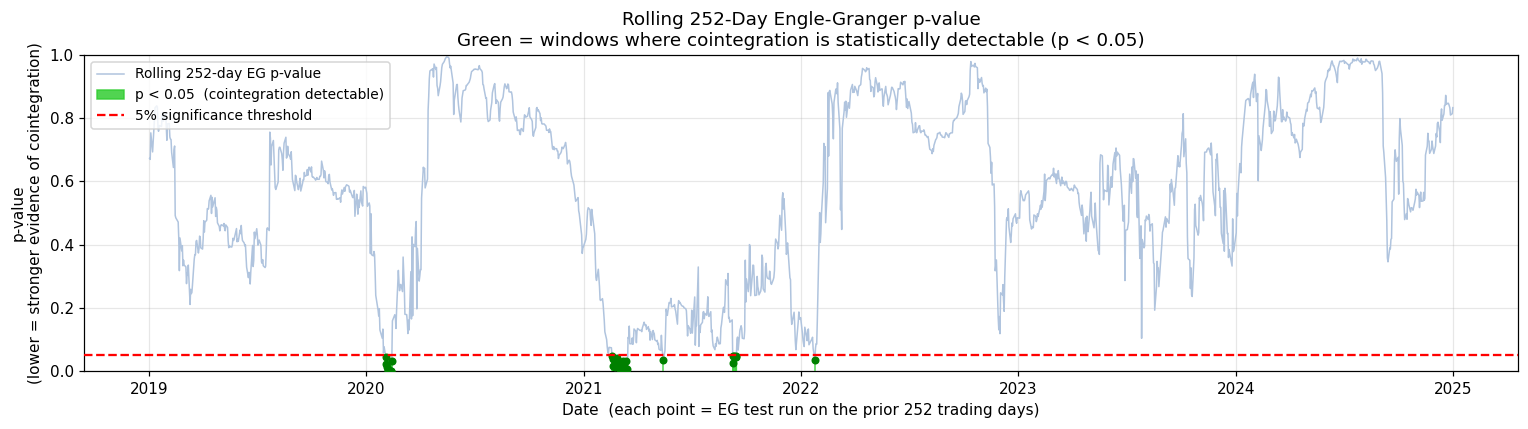

Significant windows (p < 0.05): 35 of 1510  (2.3%)
  Earliest : 2020-02-03
  Latest   : 2022-01-24
  Consecutive-day runs: 24 of 34 transitions  (clustered)


In [7]:
print("Computing rolling Engle-Granger p-values (this takes ~30 seconds)...")
roll_pval = rolling_eg_pvalue(prices, window=252)

sig = roll_pval < 0.05          # boolean mask — True on the 2.3% of windows that pass

fig, ax = plt.subplots(figsize=(14, 4))

# Full p-value line in muted color
ax.plot(roll_pval.index, roll_pval,
        color="lightsteelblue", linewidth=1.0, zorder=2, label="Rolling 252-day EG p-value")

# Highlight ONLY the significant windows — filled area under the line
ax.fill_between(roll_pval.index, 0, roll_pval,
                where=sig,
                color="limegreen", alpha=0.85, zorder=3,
                label="p < 0.05  (cointegration detectable)")

# Scatter dots on top so individual points are unmistakable
ax.scatter(roll_pval.index[sig], roll_pval[sig],
           color="green", s=18, zorder=4)

# Threshold line
ax.axhline(0.05, color="red", linestyle="--", linewidth=1.5, zorder=5,
           label="5% significance threshold")

ax.set_title(
    "Rolling 252-Day Engle-Granger p-value\n"
    "Green = windows where cointegration is statistically detectable (p < 0.05)"
)
ax.set_xlabel("Date  (each point = EG test run on the prior 252 trading days)")
ax.set_ylabel("p-value\n(lower = stronger evidence of cointegration)")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9, loc="upper left")
fmt_dates(ax)
plt.tight_layout()
plt.show()

pct_sig      = sig.mean() * 100
sig_dates    = roll_pval.index[sig]
print(f"Significant windows (p < 0.05): {sig.sum()} of {len(roll_pval)}  ({pct_sig:.1f}%)")
if sig.sum() > 0:
    print(f"  Earliest : {sig_dates[0].date()}")
    print(f"  Latest   : {sig_dates[-1].date()}")
    # Check for clustering vs scatter
    gaps = pd.Series(sig_dates).diff().dt.days.dropna()
    consecutive = (gaps == 1).sum()
    print(f"  Consecutive-day runs: {consecutive} of {len(gaps)} transitions  "
          f"({'clustered' if consecutive / len(gaps) > 0.5 else 'scattered'})")

---
## Plot 2 — Spread with cointegration regime shading

Overlaying the rolling p-value result on the spread itself tells us visually: *when* did the spread behave well, and when did the cointegration evidence break down?

**Red shading** marks periods where the trailing 252-day window showed p ≥ 0.05 — the spread was not statistically cointegrated in that window. Notice whether those periods coincide with the spread's worst drifts.

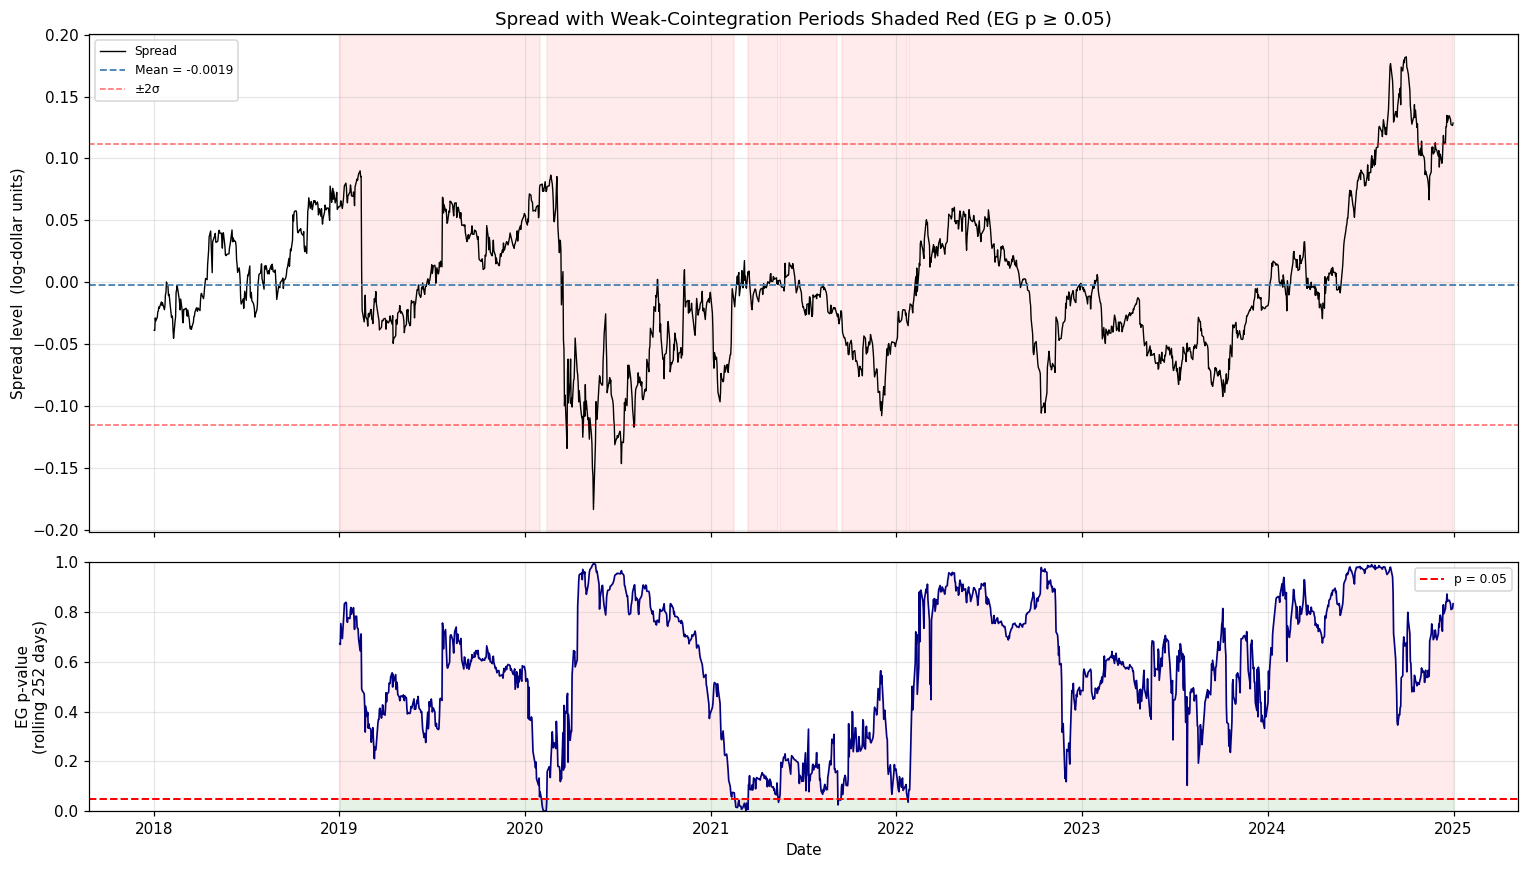

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

# Top: spread
ax = axes[0]
ax.plot(spread.index, spread, color="black", linewidth=0.9, label="Spread")
ax.axhline(spread.mean(), color="steelblue", linestyle="--", linewidth=1.2,
           label=f"Mean = {spread.mean():.4f}")
ax.axhline(spread.mean() + 2*spread.std(), color="red",
           linestyle="--", linewidth=1, alpha=0.6, label="±2σ")
ax.axhline(spread.mean() - 2*spread.std(), color="red",
           linestyle="--", linewidth=1, alpha=0.6)

# Shade windows where EG p >= 0.05
weak_coint = roll_pval[roll_pval >= 0.05].index
if len(weak_coint) > 0:
    # Fill in blocks
    in_block = False
    block_start = None
    prev_date = None
    for date in roll_pval.index:
        is_weak = roll_pval[date] >= 0.05
        if is_weak and not in_block:
            block_start = date
            in_block = True
        elif not is_weak and in_block:
            ax.axvspan(block_start, prev_date, color="red", alpha=0.08)
            in_block = False
        prev_date = date
    if in_block:
        ax.axvspan(block_start, roll_pval.index[-1], color="red", alpha=0.08)

ax.set_title("Spread with Weak-Cointegration Periods Shaded Red (EG p ≥ 0.05)")
ax.set_ylabel("Spread level  (log-dollar units)")
ax.legend(fontsize=8, loc="upper left")
fmt_dates(ax)

# Bottom: rolling p-value
ax = axes[1]
ax.plot(roll_pval.index, roll_pval, color="navy", linewidth=1.1)
ax.axhline(0.05, color="red", linestyle="--", linewidth=1.3, label="p = 0.05")
ax.fill_between(roll_pval.index, 0, 0.05, color="green", alpha=0.10)
ax.fill_between(roll_pval.index, 0.05, roll_pval.clip(upper=1),
                color="red", alpha=0.08)
ax.set_ylabel("EG p-value\n(rolling 252 days)")
ax.set_xlabel("Date")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8)
fmt_dates(ax)

plt.tight_layout()
plt.show()

---
## Summary of all three tests

In [9]:
r_ko_level   = adf_test(log_ko,         label="KO log-price")
r_pep_level  = adf_test(log_pep,        label="PEP log-price")
r_ko_ret     = adf_test(returns["KO"],  label="KO returns")
r_pep_ret    = adf_test(returns["PEP"], label="PEP returns")

print("=" * 65)
print("STEP A — Are both series I(1)?")
print("  Price levels should be non-stationary, returns stationary.")
print("=" * 65)
for r in [r_ko_level, r_pep_level, r_ko_ret, r_pep_ret]:
    print_adf(r)

print()
print("=" * 65)
print("STEP C — Engle-Granger (primary cointegration test)")
print("=" * 65)
eg2 = engle_granger_test(prices)
verdict_eg = "REJECT H₀ → Cointegrated" if eg2["cointegrated_at_5pct"] else "FAIL TO REJECT → No cointegration detected"
print(f"  stat={eg2['stat']:.4f}  p={eg2['pval']:.4f}  5%CV={eg2['crit_5pct']:.3f}")
print(f"  → {verdict_eg}")

print()
print("=" * 65)
print("STEP D — Johansen (symmetric cross-check)")
print("=" * 65)
joh2     = johansen_test(prices["2018":"2024"])
trace_r0 = joh2.lr1[0]
cv95_r0  = joh2.cvt[0, 1]
verdict_joh = "REJECT H₀ → Cointegrated" if trace_r0 > cv95_r0 else "FAIL TO REJECT"
print(f"  trace(r=0)={trace_r0:.3f}  95%CV={cv95_r0:.3f}")
print(f"  → {verdict_joh}")

print()
print("=" * 65)
print("ROLLING — % of 252-day windows with EG p < 0.05")
print("=" * 65)
print(f"  {(roll_pval < 0.05).mean()*100:.1f}% of rolling windows show detectable cointegration")
print()
print("OVERALL VERDICT:")
both_agree = eg2["cointegrated_at_5pct"] and (trace_r0 > cv95_r0)
if both_agree:
    print("  Engle-Granger and Johansen AGREE: evidence of cointegration. ✓")
    print("  Proceed to backtest with statistical confidence.")
else:
    print("  Tests DISAGREE or both fail — investigate before backtesting.")

STEP A — Are both series I(1)?
  Price levels should be non-stationary, returns stationary.
  KO log-price                    stat= -1.343  p=0.6093  5%crit=-2.863  lags=12  → non-stationary (unit root not rejected)
  PEP log-price                   stat= -1.504  p=0.5315  5%crit=-2.863  lags=9  → non-stationary (unit root not rejected)
  KO returns                      stat=-12.869  p=0.0000  5%crit=-2.863  lags=11  → STATIONARY
  PEP returns                     stat=-12.597  p=0.0000  5%crit=-2.863  lags=8  → STATIONARY

STEP C — Engle-Granger (primary cointegration test)
  stat=-2.4322  p=0.3098  5%CV=-3.340
  → FAIL TO REJECT → No cointegration detected

STEP D — Johansen (symmetric cross-check)
  trace(r=0)=10.384  95%CV=15.494
  → FAIL TO REJECT

ROLLING — % of 252-day windows with EG p < 0.05
  2.3% of rolling windows show detectable cointegration

OVERALL VERDICT:
  Tests DISAGREE or both fail — investigate before backtesting.


---
## How to interpret these results

### If Engle-Granger rejects (p < 0.05)
The spread is statistically cointegrated over the full 7-year sample. Combined with a significant Johansen result, this is strong evidence that the pair trades around a stable long-run relationship.

But notice the caveats from the rolling analysis:
- The p-value fluctuates over time — some years show weak cointegration
- This is exactly why the backtest uses a **walk-forward** structure: we only trade in a test window if the *preceding training window* shows cointegration

### The most important mistake to avoid

If the test **fails to reject** at 5%, the correct statement is:

> *"We do not have sufficient statistical evidence of cointegration in this sample."*

NOT:

> *"The pair is not cointegrated."*

This is the distinction between "absence of evidence" and "evidence of absence." With 1,761 observations the test has reasonable power, but if the half-life is long (as we found in Step 4 — 72 days), the test may still struggle to detect slow mean reversion even when it's real.

---
**Next: Step 7 — Trading Rule Design.** With the statistical foundation in place, we define the entry/exit z-score thresholds and position logic.